In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df=pd.read_csv("openaq_dataset.csv")

### Sample data

In [3]:
df.sample(2)

,location,city,country,pollutant,value,unit,timestamp,unit_1,source_name,latitude,longitude,averaged_over_in_hours,location_geom
307441,Longford,Tasmania Region,AU,pm25,2.0,µg/m³,2022-05-07 07:34:07+00:00,µg/m³,Australia - Tasmania,0.25,-41.595000,147.122000,POINT(-41.595 0.25)
966558,FR18089,Oise,FR,pm25,8.9,µg/m³,2022-04-15 02:00:00+00:00,µg/m³,EEA France,1.00,49.435954,2.084289,POINT(49.435953836447 1)


### All column name

In [4]:
df.columns

Index(['location', 'city', 'country', 'pollutant', 'value', 'unit',
       'timestamp', 'unit_1', 'source_name', 'latitude', 'longitude',
       'averaged_over_in_hours', 'location_geom'],
      dtype='object')

### Dataset info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200025 entries, 0 to 1200024
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   location                1200018 non-null  object 
 1   city                    1172537 non-null  object 
 2   country                 1200025 non-null  object 
 3   pollutant               1200025 non-null  object 
 4   value                   1200025 non-null  float64
 5   unit                    1200025 non-null  object 
 6   timestamp               1200025 non-null  object 
 7   unit_1                  1200025 non-null  object 
 8   source_name             1200025 non-null  object 
 9   latitude                1200025 non-null  float64
 10  longitude               1200025 non-null  float64
 11  averaged_over_in_hours  1200025 non-null  float64
 12  location_geom           1200025 non-null  object 
dtypes: float64(4), object(9)
memory usage: 119.0+ MB


### Shape

In [6]:
df.shape

(1200025, 13)

# Data Cleaning

In [7]:
new_df = df.dropna(subset=['location','city'])

In [8]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1172530 entries, 0 to 1200024
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   location                1172530 non-null  object 
 1   city                    1172530 non-null  object 
 2   country                 1172530 non-null  object 
 3   pollutant               1172530 non-null  object 
 4   value                   1172530 non-null  float64
 5   unit                    1172530 non-null  object 
 6   timestamp               1172530 non-null  object 
 7   unit_1                  1172530 non-null  object 
 8   source_name             1172530 non-null  object 
 9   latitude                1172530 non-null  float64
 10  longitude               1172530 non-null  float64
 11  averaged_over_in_hours  1172530 non-null  float64
 12  location_geom           1172530 non-null  object 
dtypes: float64(4), object(9)
memory usage: 125.2+ MB


In [9]:
new_df.shape

(1172530, 13)

In [10]:
new_df=new_df.drop_duplicates()

In [11]:
new_df.shape

(1172530, 13)

In [12]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1172530 entries, 0 to 1200024
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   location                1172530 non-null  object 
 1   city                    1172530 non-null  object 
 2   country                 1172530 non-null  object 
 3   pollutant               1172530 non-null  object 
 4   value                   1172530 non-null  float64
 5   unit                    1172530 non-null  object 
 6   timestamp               1172530 non-null  object 
 7   unit_1                  1172530 non-null  object 
 8   source_name             1172530 non-null  object 
 9   latitude                1172530 non-null  float64
 10  longitude               1172530 non-null  float64
 11  averaged_over_in_hours  1172530 non-null  float64
 12  location_geom           1172530 non-null  object 
dtypes: float64(4), object(9)
memory usage: 125.2+ MB


In [ ]:
# new_df.to_csv("Cleaned_AQ.csv",index=False)

# Only India Dataset

In [13]:
df_India=new_df[new_df['country']=="IN"]

In [14]:
new_df.shape

(1172530, 13)

In [15]:
df_India.shape

(134144, 13)

In [16]:
df_India.info()

<class 'pandas.core.frame.DataFrame'>
Index: 134144 entries, 24655 to 1129214
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   location                134144 non-null  object 
 1   city                    134144 non-null  object 
 2   country                 134144 non-null  object 
 3   pollutant               134144 non-null  object 
 4   value                   134144 non-null  float64
 5   unit                    134144 non-null  object 
 6   timestamp               134144 non-null  object 
 7   unit_1                  134144 non-null  object 
 8   source_name             134144 non-null  object 
 9   latitude                134144 non-null  float64
 10  longitude               134144 non-null  float64
 11  averaged_over_in_hours  134144 non-null  float64
 12  location_geom           134144 non-null  object 
dtypes: float64(4), object(9)
memory usage: 14.3+ MB


# Feature Engineering

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# convert text columns to numeric
new_df['city'] = le.fit_transform(new_df['city'].astype(str))
new_df['country'] = le.fit_transform(new_df['country'].astype(str))

In [18]:
new_df[['city','country']].sample(5)

,city,country
225988,1318,40
623818,344,29
289749,797,84
989119,169,79
19001,917,27


In [19]:
new_df['timestamp'] = pd.to_datetime(new_df['timestamp'], errors='coerce')

In [20]:
new_df['date'] = pd.to_datetime(new_df['timestamp'])
new_df['year'] = new_df['timestamp'].dt.year
new_df['month'] = new_df['timestamp'].dt.month

In [21]:
new_df.shape

(1172530, 16)

In [22]:
new_df.sample(2)

,location,city,country,pollutant,value,unit,timestamp,unit_1,source_name,latitude,longitude,averaged_over_in_hours,location_geom,date,year,month
548067,Santa Clarita,1008,84,pm25,6.5,µg/m³,2022-05-16 16:00:00+00:00,µg/m³,AirNow,1.00,34.3833,-118.5283,POINT(34.3833 1),2022-05-16 16:00:00+00:00,2022,5
482503,"Vasai West, Mumbai - MPCB",1146,40,pm25,77.4,µg/m³,2022-05-05 08:00:00+00:00,µg/m³,caaqm,0.25,19.3832,72.8204,POINT(19.3832 0.25),2022-05-05 08:00:00+00:00,2022,5


# Data Analysis

### Country wise pollution

In [23]:
country_pollution = df.groupby('country')['value'].mean().sort_values(ascending=False)
country_pollution.head(10)

country
SG    282.900000
IZ     99.324561
KU     95.107143
AE     77.510363
NI     63.885714
IN     63.305504
QA     55.656757
CL     41.929945
BH     41.890838
SA     38.000000
Name: value, dtype: float64

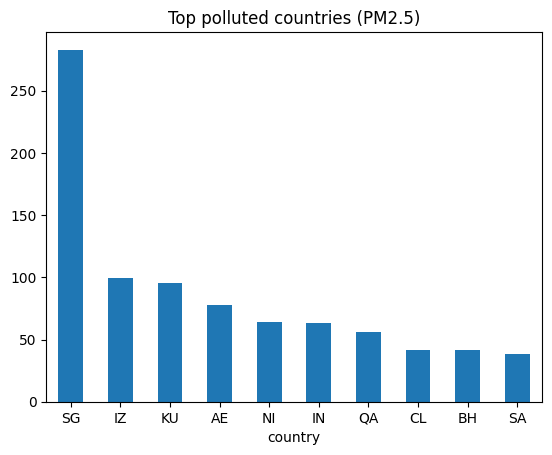

In [24]:
country_pollution.head(10).plot(kind='bar')
plt.title("Top polluted countries (PM2.5)")
plt.xticks(rotation=0)
plt.show()

### Year wise pollution

In [25]:
new_df['value'] = pd.to_numeric(new_df['value'], errors='coerce')  #numeric pollution value

In [26]:
yearly_pollution = new_df.groupby('year')['value'].mean().reset_index()

In [27]:
yearly_pollution

,year,value
0,2007,25.368333
1,2008,33.724000
2,2014,12.400000
3,2015,57.791000
4,2016,-3.201500
5,2017,26.663082
6,2018,28.046857
7,2019,17.278466
8,2020,-2.440090
9,2021,12.598407


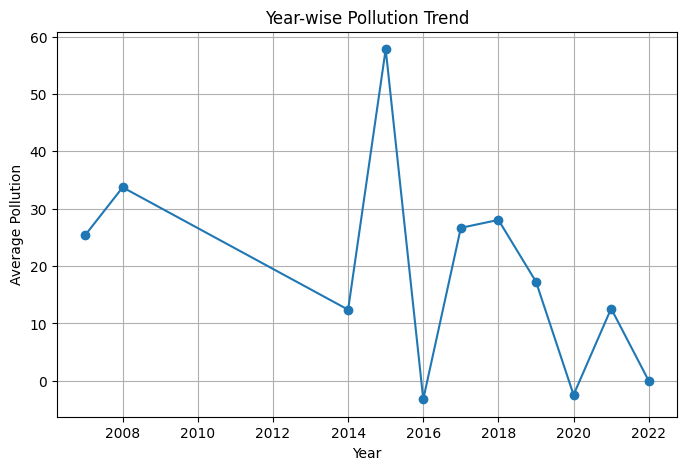

In [28]:
plt.figure(figsize=(8,5))
plt.plot(yearly_pollution['year'], yearly_pollution['value'], marker='o')
plt.title("Year-wise Pollution Trend")
plt.xlabel("Year")
plt.ylabel("Average Pollution")
plt.grid(True)
plt.show()

### Top cities

In [29]:
top_10_cities = df.groupby('location')['value'].mean().sort_values(ascending=False).head(10)

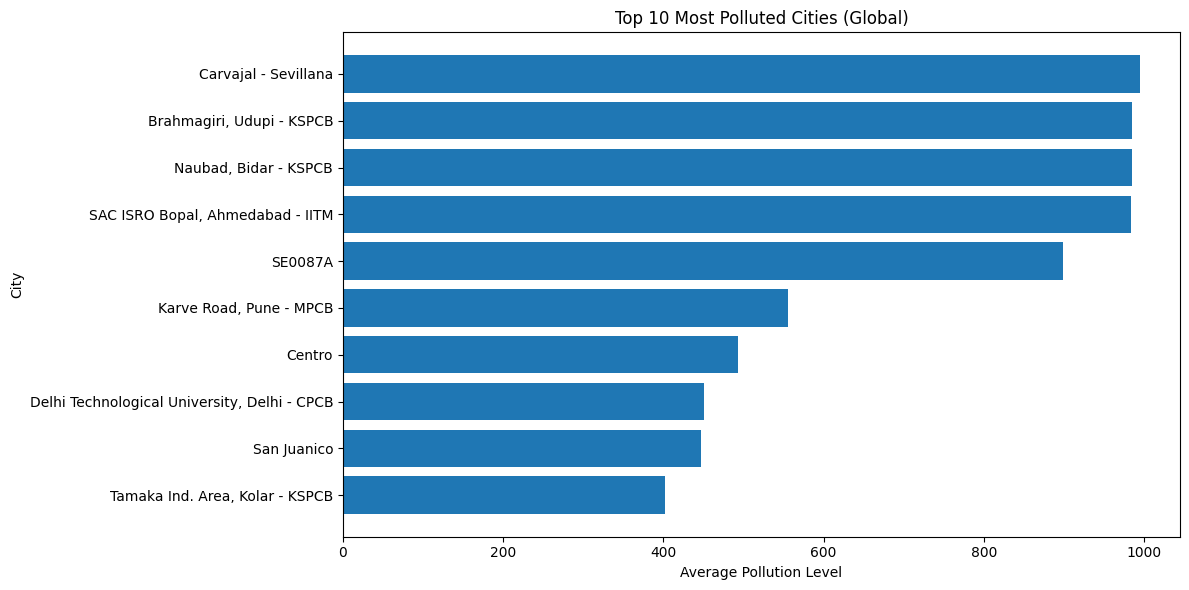

In [30]:
plt.figure(figsize=(12,6))
plt.barh(top_10_cities.index, top_10_cities.values)
plt.title("Top 10 Most Polluted Cities (Global)")
plt.xlabel("Average Pollution Level")
plt.ylabel("City")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Monthly highest pollution

In [31]:
monthly_pollution = new_df.groupby('month')['value'].mean().reset_index()

In [32]:
print("Dataset start date:", df['timestamp'].min())
print("Dataset end date:", df['timestamp'].max())


Dataset start date: 2007-02-09 07:00:00+00:00
Dataset end date: 2022-05-26 18:00:00+00:00


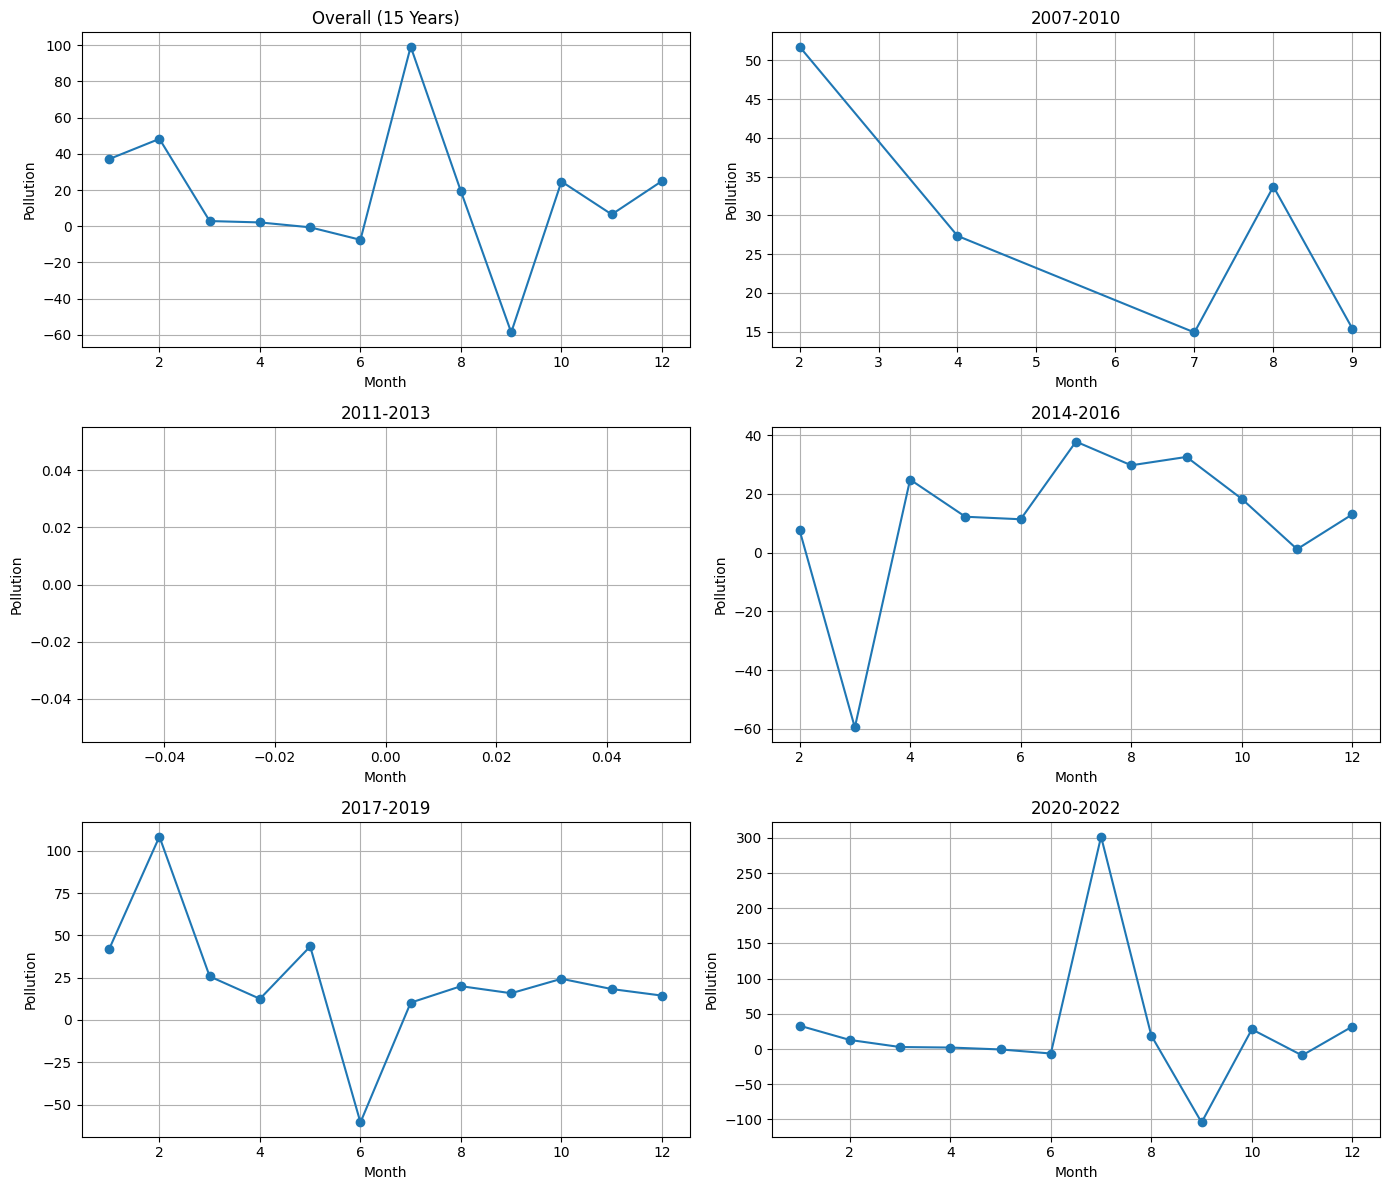

In [33]:
new_df['year'] = new_df['timestamp'].dt.year
new_df['month'] = new_df['timestamp'].dt.month

fig, axes = plt.subplots(3, 2, figsize=(14,12))

#Overall
overall = new_df.groupby('month')['value'].mean()
axes[0,0].plot(overall.index, overall.values, marker='o')
axes[0,0].set_title("Overall (15 Years)")
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Pollution")
axes[0,0].grid(True)

# year Wise
year_groups = [
    (2007,2010),
    (2011,2013),
    (2014,2016),
    (2017,2019),
    (2020,2022)
]

positions = [(0,1),(1,0),(1,1),(2,0),(2,1)]

for (start,end), pos in zip(year_groups, positions):
    temp = new_df[(new_df['year']>=start) & (new_df['year']<=end)]
    monthly = temp.groupby('month')['value'].mean()
    
    ax = axes[pos]
    ax.plot(monthly.index, monthly.values, marker='o')
    ax.set_title(f"{start}-{end}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Pollution")
    ax.grid(True)

plt.tight_layout()
plt.show()


### Heatmap

In [34]:
num_df = new_df[['value','year','month','country','city']]

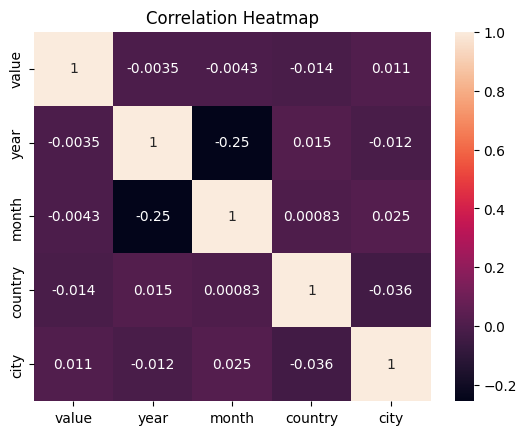

In [35]:
sns.heatmap(num_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Prepare ML data

In [36]:
ml_df = new_df.copy()

In [37]:
ml_df.shape

(1172530, 16)

In [38]:
ml_df['year'] = ml_df['timestamp'].dt.year
ml_df['month'] = ml_df['timestamp'].dt.month
ml_df['day'] = ml_df['timestamp'].dt.day

In [39]:
ml_df = ml_df[['country','city','year','month','day','value']]  # keep useful columns

In [40]:
ml_df.shape

(1172530, 6)

In [41]:
dup = ml_df.duplicated(subset=['country','city','year','month','day'], keep=False)

# see them (optional)
print(ml_df[dup].sort_values(['country','city','year','month','day']))

# remove duplicates → keep first correct entry
ml_df = ml_df.drop_duplicates(
    subset=['country','city','year','month','day'],
    keep='first'
)

print("Duplicates removed ✔")
print("New shape:", ml_df.shape)

         country  city  year  month  day   value
648541         0    35  2022      3   31 -999.00
752664         0    35  2022      3   31 -999.00
49297          0    35  2022      4   27   21.00
300446         0    35  2022      4   27   24.00
347040         0    35  2022      4   27   21.00
...          ...   ...   ...    ...  ...     ...
1049559       88  1921  2022      5   23   14.24
1199435       88  1921  2022      5   23    3.49
420406        88  1921  2022      5   24    3.49
449565        88  1921  2022      5   24    3.49
720950        88  1921  2022      5   24    3.49

[1147505 rows x 6 columns]
Duplicates removed ✔
New shape: (79199, 6)


In [42]:
ml_df.shape

(79199, 6)

count    79199.000000
mean        -1.885112
std        191.371644
min      -9999.000000
25%          4.000000
50%          8.000000
75%         16.599500
max      10000.000000
Name: value, dtype: float64


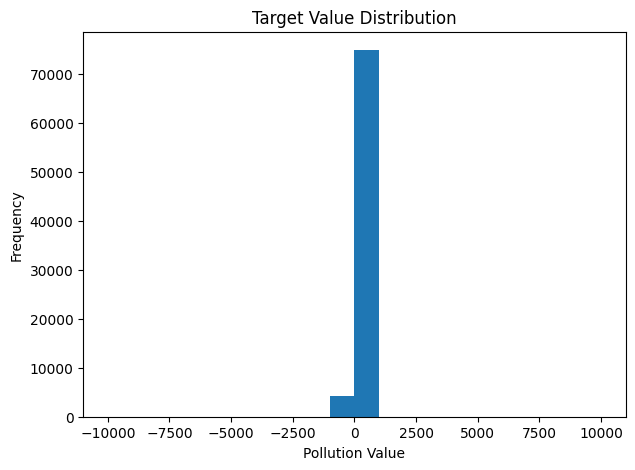


City distribution:
city
988     118
1439    116
585     115
1462    115
285     114
       ... 
125       1
331       1
1745      1
1117      1
1554      1
Name: count, Length: 2340, dtype: int64

Year distribution:
year
2007        4
2008        2
2014        4
2015       12
2016       87
2017      168
2018      240
2019      230
2020     1702
2021      764
2022    75986
Name: count, dtype: int64


In [43]:
# check distribution of target variable (pollution value)
print(ml_df['value'].describe())

plt.figure(figsize=(7,5))
plt.hist(ml_df['value'], bins=20)
plt.title("Target Value Distribution")
plt.xlabel("Pollution Value")
plt.ylabel("Frequency")
plt.show()


# check city distribution (feature balance)
print("\nCity distribution:")
print(ml_df['city'].value_counts())

# check year distribution
print("\nYear distribution:")
print(ml_df['year'].value_counts().sort_index())


In [44]:
ml_df['value'] = ml_df['value'].apply(lambda x: 500 if x > 500 else x)

In [45]:
ml_df = ml_df[(ml_df['value'] >= 0)]


Skewness: 7.471685156849733


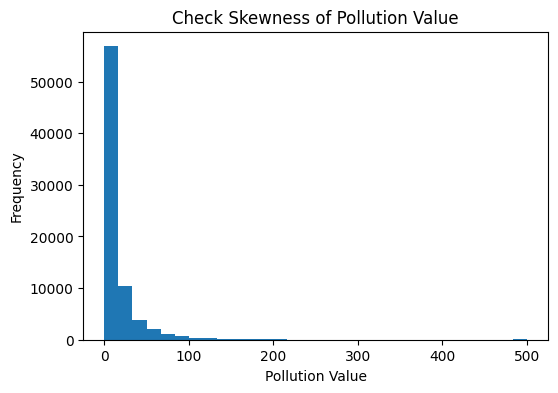

In [46]:
# check skewness of pollution value
print("Skewness:", ml_df['value'].skew())

# visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(ml_df['value'], bins=30)
plt.title("Check Skewness of Pollution Value")
plt.xlabel("Pollution Value")
plt.ylabel("Frequency")
plt.show()


In [47]:
ml_df.shape

(76579, 6)

count    76579.000000
mean        17.247052
std         31.663445
min          0.000000
25%          4.133090
50%          8.000000
75%         17.000000
max        500.000000
Name: value, dtype: float64
value
0.000000      1271
0.010000         1
0.013589         1
0.018467         1
0.020000         1
              ... 
468.990000       1
474.000000       1
477.400000       1
494.000000       1
500.000000      92
Name: count, Length: 13256, dtype: int64


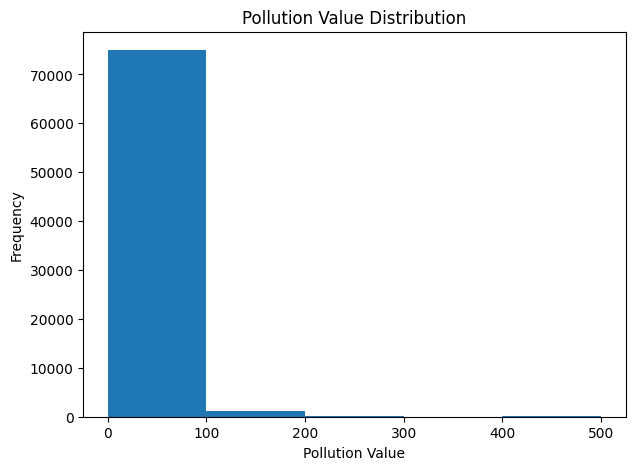

In [48]:
# value distribution statistics
print(ml_df['value'].describe())

# frequency distribution
print(ml_df['value'].value_counts().sort_index())

# histogram plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(ml_df['value'], bins=5)
plt.title("Pollution Value Distribution")
plt.xlabel("Pollution Value")
plt.ylabel("Frequency")
plt.show()


In [49]:
ml_df.shape

(76579, 6)

In [50]:
draft_df=ml_df.copy()

In [51]:
draft_df.shape

(76579, 6)

## Binning


In [132]:
# create pollution category
bins = [0,50,100,200,300,500]
labels = ['Good','Moderate','Unhealthy','Very_Unhealthy','Hazard']

ml_df['pollution_cat'] = pd.cut(ml_df['value'], bins=bins, labels=labels, include_lowest=True)

# check count
print(ml_df['pollution_cat'].value_counts())

# balance dataset (take equal from each)
balanced_df = ml_df.groupby('pollution_cat').apply(lambda x: x.sample(15000, replace=True)).reset_index(drop=True)

print(balanced_df['pollution_cat'].value_counts())


pollution_cat
Good              71155
Moderate           3847
Unhealthy          1259
Very_Unhealthy      164
Hazard              154
Name: count, dtype: int64
pollution_cat
Good              15000
Moderate          15000
Unhealthy         15000
Very_Unhealthy    15000
Hazard            15000
Name: count, dtype: int64


C:\Users\sjits\AppData\Local\Temp\ipykernel_9808\720563275.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  balanced_df = ml_df.groupby('pollution_cat').apply(lambda x: x.sample(15000, replace=True)).reset_index(drop=True)
C:\Users\sjits\AppData\Local\Temp\ipykernel_9808\720563275.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = ml_df.groupby('pollution_cat').apply(lambda x: x.sample(15000, replace=True)).reset_index(drop=True)


In [115]:
balanced_df.shape

(75000, 7)

In [54]:
balanced_df.columns

Index(['country', 'city', 'year', 'month', 'day', 'value', 'pollution_cat'], dtype='object')

In [55]:
balanced_df = balanced_df.drop('pollution_cat', axis=1)

Skewness: 0.8517058766436862


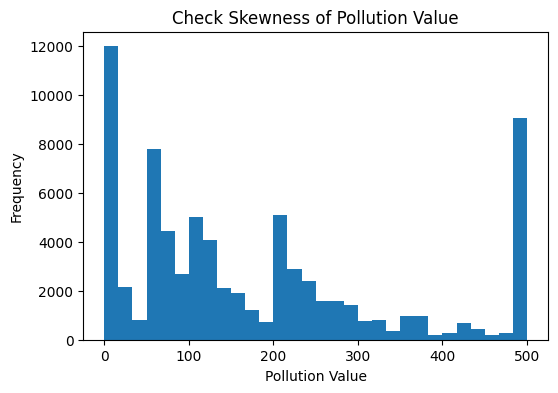

In [56]:
# check skewness of pollution value
print("Skewness:", balanced_df['value'].skew())

plt.figure(figsize=(6,4))
plt.hist(balanced_df['value'], bins=30)
plt.title("Check Skewness of Pollution Value")
plt.xlabel("Pollution Value")
plt.ylabel("Frequency")
plt.show()

In [57]:
balanced_df.sample(2)

,country,city,year,month,day,value
65721,40,1780,2021,7,25,500.0
69591,40,705,2022,5,23,500.0


In [58]:
y = balanced_df['value']  # target variable (pollution value)

In [59]:
X = balanced_df.drop('value', axis=1) # features

In [60]:
# ml_df.to_csv("Cleaned_AQ_ml.csv",index=False)

In [61]:
balanced_df.shape

(75000, 6)

In [62]:
X.shape

(75000, 5)

In [63]:
y.shape

(75000,)

### Train Test split

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=25
)

In [65]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 5)
Test shape: (15000, 5)


In [66]:
X_train.values

array([[  40, 1624, 2022,    4,   16],
       [  40,  596, 2022,    4,    2],
       [  14,  441, 2022,    5,   20],
       ...,
       [  40, 1326, 2022,    4,   16],
       [  40,  369, 2022,    5,    5],
       [  40,  207, 2022,    4,   10]])

In [67]:
X_train.value_counts()

country  city  year  month  day
88       1087  2022  5      14     100
74       877   2022  5      16      98
40       604   2022  4      3       98
         562   2018  2      22      97
84       309   2022  5      6       97
                                  ... 
88       1602  2022  4      9        1
         1921  2022  4      22       1
                            17       1
                            1        1
         1920  2022  5      13       1
Name: count, Length: 16324, dtype: int64

In [68]:
y_train.values

array([242.  , 195.4 , 270.  , ..., 126.2 ,  26.96,  90.9 ])

In [69]:
y_train.value_counts()

value
500.0000    7129
4.0000       397
5.0000       366
6.0000       360
202.0000     333
            ... 
16.5900        1
84.9800        1
20.0933        1
28.9300        1
13.7910        1
Name: count, Length: 4386, dtype: int64

In [70]:
X_test.values

array([[  40,  160, 2022,    4,   13],
       [  78, 1157, 2022,    4,   21],
       [  40,  847, 2022,    5,   19],
       ...,
       [  84, 1166, 2022,    4,    7],
       [  25,  279, 2022,    5,    8],
       [  40,  161, 2022,    4,    7]])

In [71]:
y_test.values

array([241.  , 292.  ,  72.65, ...,   5.  ,  18.  , 221.99])

## Linear Regression (sklearn inbuilt)

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [73]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
y_pred_1= model.predict(X_test)

# evaluation
print("R2 Score:", r2_score(y_test, y_pred_1))
print("MAE:", mean_absolute_error(y_test, y_pred_1))
print("RMSE:", mean_squared_error(y_test, y_pred_1)**0.5)

R2 Score: 0.03810541738403217
MAE: 127.75020006241701
RMSE: 157.07619157473076


## OLS Regression (statsmodels)

In [75]:
# -------- OLS Regression (statsmodels) --------

import statsmodels.api as sm

# convert categorical columns to dummy variables
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc  = pd.get_dummies(X_test, drop_first=True)

# align test columns with train columns
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# add constant (intercept)
X_train_enc = sm.add_constant(X_train_enc)
X_test_enc  = sm.add_constant(X_test_enc)

# build OLS model
model = sm.OLS(y_train, X_train_enc).fit()

# model summary
print(model.summary())

# predictions
y_pred_2 = model.predict(X_test_enc)

# evaluation


print("MAE:", mean_absolute_error(y_test, y_pred_2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_2)))
print("R2 Score:", r2_score(y_test, y_pred_2))


                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     496.4
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:27:39   Log-Likelihood:            -3.8790e+05
No. Observations:               60000   AIC:                         7.758e+05
Df Residuals:                   59994   BIC:                         7.759e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.437e+04   1726.135     14.117      0.0

## Gradient Descent Regression (sklearn SGD)

In [76]:
# -------- Gradient Descent Regression using SGD --------

from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# categorical + numeric columns
cat_cols = ['country','city']
num_cols = ['year','month','day']

# preprocessing: encode categorical + scale numeric
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# SGD Regression model
model = SGDRegressor(max_iter=5000, learning_rate='constant', eta0=0.0001, random_state=25)

# pipeline
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', model)
])

# train
pipeline.fit(X_train, y_train)

# predict
y_pred = pipeline.predict(X_test)

# evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 7741.391670245048
RMSE: 87.98517869644323
R2 Score: 0.6981954424665615


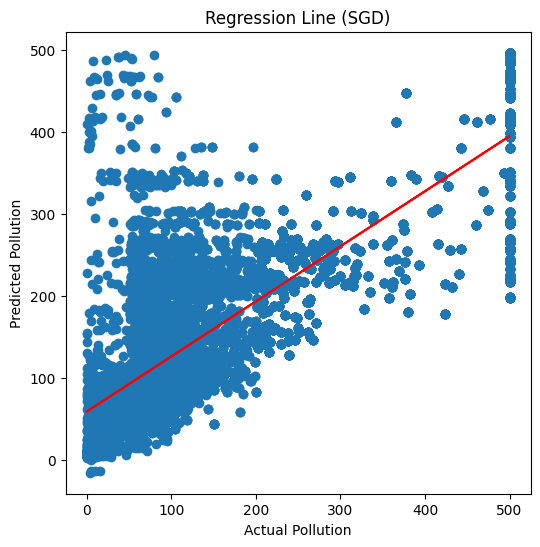

In [77]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

# regression line (red color)
z = np.polyfit(y_test, y_pred, 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test), color='red')

plt.xlabel("Actual Pollution")
plt.ylabel("Predicted Pollution")
plt.title("Regression Line (SGD)")
plt.show()


# Oversampling Data

In [81]:
balanced_df.shape

(75000, 6)

In [82]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  75000 non-null  int64  
 1   city     75000 non-null  int64  
 2   year     75000 non-null  int32  
 3   month    75000 non-null  int32  
 4   day      75000 non-null  int32  
 5   value    75000 non-null  float64
dtypes: float64(1), int32(3), int64(2)
memory usage: 2.6 MB


In [83]:
balanced_df['value'].unique()

array([  7.9 ,   2.  ,   9.83, ..., 426.65, 360.  , 389.67])

In [84]:
balanced_df['value']

0          7.90
1          2.00
2          9.83
3          8.00
4         39.00
          ...  
74995    500.00
74996    334.70
74997    361.80
74998    315.03
74999    414.00
Name: value, Length: 75000, dtype: float64

In [85]:

from sklearn.utils import resample

# Target size
target_size = 100000

# Oversample
df_oversampled = resample(
    balanced_df,
    replace=True,          # allow duplicate rows
    n_samples=target_size, # desired size
    random_state=25
)

print(df_oversampled.shape)

# Save dataset
df_oversampled.to_csv("oversampled_100k.csv", index=False)

(100000, 6)


In [86]:
df_oversampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 29828 to 23825
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   country  100000 non-null  int64  
 1   city     100000 non-null  int64  
 2   year     100000 non-null  int32  
 3   month    100000 non-null  int32  
 4   day      100000 non-null  int32  
 5   value    100000 non-null  float64
dtypes: float64(1), int32(3), int64(2)
memory usage: 4.2 MB


In [87]:
df_oversampled['value'].unique

<bound method Series.unique of 29828     90.90
6618      26.96
35702    126.20
33943    132.60
59314    201.90
          ...  
189       12.00
10192      4.00
34357    102.00
71918    500.00
23825     51.52
Name: value, Length: 100000, dtype: float64>

In [88]:
df_oversampled.sample(5)

,country,city,year,month,day,value
14526,14,1392,2022,5,23,34.0
19342,40,1636,2022,5,22,65.4
11502,68,1632,2022,5,6,5.6
47656,15,2214,2020,12,31,207.0
58109,40,604,2022,4,3,249.0


Skewness: 0.8553280322984971


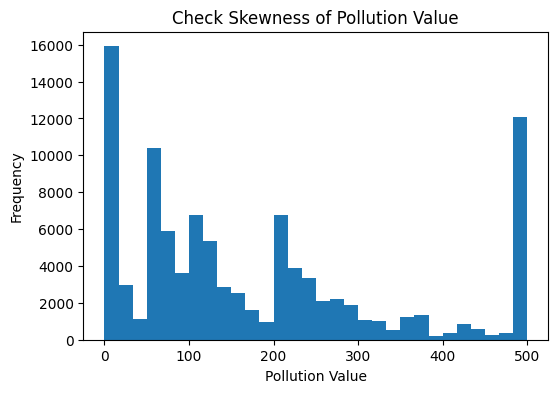

In [90]:
# check skewness of pollution value
print("Skewness:", df_oversampled['value'].skew())

plt.figure(figsize=(6,4))
plt.hist(df_oversampled['value'], bins=30)
plt.title("Check Skewness of Pollution Value")
plt.xlabel("Pollution Value")
plt.ylabel("Frequency")
plt.show()

In [91]:
y_over_sample = df_oversampled['value']  # target variable (pollution value)

In [92]:
X_over_sample = df_oversampled.drop('value', axis=1) # features

In [93]:
X_over_sample.shape

(100000, 5)

In [94]:
y_over_sample.shape

(100000,)

### Train Test  Split

In [95]:


X_over_train, X_over_test, y_over_train, y_over_test = train_test_split(
    X_over_sample, y_over_sample, test_size=0.2, random_state=25
)

In [96]:
print("Train shape:", X_over_train.shape)
print("Test shape:", X_over_test.shape)

Train shape: (80000, 5)
Test shape: (20000, 5)


In [97]:
X_over_train.values

array([[  79, 1790, 2022,    5,   22],
       [  14,  394, 2022,    4,   28],
       [  84, 1487, 2022,    4,   29],
       ...,
       [  40, 1466, 2022,    4,    4],
       [  40,  823, 2022,    5,   16],
       [  40,   42, 2022,    4,   15]])

In [98]:
X_over_train.value_counts()

country  city  year  month  day
40       604   2022  4      3      143
         1624  2022  4      16     141
74       877   2022  5      16     140
14       394   2022  5      17     136
40       848   2022  4      4      135
                                  ... 
68       1258  2022  3      30       1
         1242  2022  5      23       1
                     4      25       1
88       1921  2022  4      28       1
                            9        1
Name: count, Length: 14333, dtype: int64

In [ ]:
y_over_train.values

array([ 14.  ,  56.  ,  30.  , ..., 136.94, 161.02, 291.43])

In [100]:
y_over_train.value_counts()

value
500.00000    9629
4.00000       537
5.00000       536
6.00000       475
202.00000     443
             ... 
49.32000        1
9.16067         1
34.71900        1
1.27000         1
73.64700        1
Name: count, Length: 4092, dtype: int64

In [101]:
X_over_test.value_counts

<bound method DataFrame.value_counts of        country  city  year  month  day
34517       40   868  2022      4    6
37280       40  1579  2022      5   26
14433       84   824  2022      5    9
44776       14   394  2022      5   12
15359       40   282  2022      4   10
...        ...   ...   ...    ...  ...
21862       58  1783  2022      5   23
18931       40   509  2022      3   31
65267       40   848  2022      4   29
60693       15   653  2022      4   11
15718       14   123  2022      4   30

[20000 rows x 5 columns]>

In [102]:
y_over_test.value_counts

<bound method IndexOpsMixin.value_counts of 34517    119.00
37280    112.00
14433      9.90
44776    122.00
15359     91.00
          ...  
21862     67.00
18931     65.43
65267    377.63
60693    500.00
15718     52.00
Name: value, Length: 20000, dtype: float64>

## Linear Regression (sklearn inbuilt)

In [103]:
model = LinearRegression()
model.fit(X_over_train, y_over_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [104]:
y_pred_over_1= model.predict(X_over_test)

In [105]:
# evaluation
print("R2 Score:", r2_score(y_over_test, y_pred_over_1))
print("MAE:", mean_absolute_error(y_over_test, y_pred_over_1))
print("RMSE:", mean_squared_error(y_over_test, y_pred_over_1)**0.5)

R2 Score: 0.03941629584145934
MAE: 126.13098849695909
RMSE: 154.8508490285959


## OLS Regression (statsmodels)

In [107]:
import statsmodels.api as sm

# convert categorical columns to dummy variables
X_over_train_enc = pd.get_dummies(X_over_train, drop_first=True)
X_over_test_enc  = pd.get_dummies(X_over_test, drop_first=True)

# align test columns with train columns
X_over_test_enc = X_over_test_enc.reindex(columns=X_over_train_enc.columns, fill_value=0)

# add constant (intercept)
X_over_train_enc = sm.add_constant(X_over_train_enc)
X_over_test_enc  = sm.add_constant(X_over_test_enc)

# build OLS model
model = sm.OLS(y_over_train, X_over_train_enc).fit()

# model summary
print(model.summary())

# predictions
y_pred_over_2 = model.predict(X_over_test_enc)

# evaluation


print("MAE:", mean_absolute_error(y_over_test, y_pred_over_2))
print("RMSE:", np.sqrt(mean_squared_error(y_over_test, y_pred_over_2)))
print("R2 Score:", r2_score(y_over_test, y_pred_over_2))

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     634.1
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:35:48   Log-Likelihood:            -5.1740e+05
No. Observations:               80000   AIC:                         1.035e+06
Df Residuals:                   79994   BIC:                         1.035e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.247e+04   1485.553     15.128      0.0

## Gradient Descent Regression (sklearn SGD)

In [109]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# categorical + numeric columns
cat_cols = ['country','city']
num_cols = ['year','month','day']

# preprocessing: encode categorical + scale numeric
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# SGD Regression model
model = SGDRegressor(max_iter=100, learning_rate='constant', eta0=0.0035, random_state=25)

# pipeline
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', model)
])

# train
pipeline.fit(X_over_train, y_over_train)

# predict
y_pred_over_3 = pipeline.predict(X_over_test)

# evaluation
print("MSE:", mean_squared_error(y_over_test, y_pred_over_3))
print("RMSE:", np.sqrt(mean_squared_error(y_over_test, y_pred_over_3)))
print("R2 Score:", r2_score(y_over_test, y_pred_over_3))

MSE: 7935.9126443505675
RMSE: 89.08373950587485
R2 Score: 0.6820894710737935


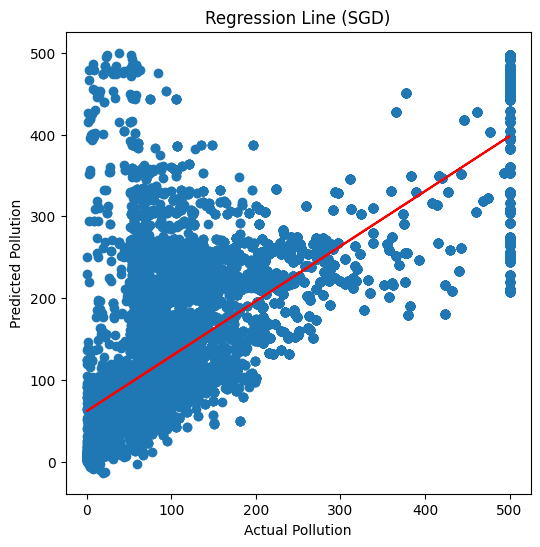

In [110]:
plt.figure(figsize=(6,6))
plt.scatter(y_over_test, y_pred_over_3)

# regression line (red color)
z = np.polyfit(y_over_test, y_pred_over_3, 1)
p = np.poly1d(z)
plt.plot(y_over_test, p(y_over_test), color='red')

plt.xlabel("Actual Pollution")
plt.ylabel("Predicted Pollution")
plt.title("Regression Line (SGD)")
plt.show()


In [111]:
y_over_sample.value_counts()

value
500.000000    11990
4.000000        680
5.000000        666
6.000000        587
202.000000      555
              ...  
2.525000          1
8.470000          1
6.010000          1
3.210508          1
26.960000         1
Name: count, Length: 4281, dtype: int64

# Under Sampling

In [113]:
balanced_df = balanced_df.iloc[:, :-3]

print(balanced_df.head())
print(balanced_df.shape)

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
(75000, 0)


In [133]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   country        75000 non-null  int64   
 1   city           75000 non-null  int64   
 2   year           75000 non-null  int32   
 3   month          75000 non-null  int32   
 4   day            75000 non-null  int32   
 5   value          75000 non-null  float64 
 6   pollution_cat  75000 non-null  category
dtypes: category(1), float64(1), int32(3), int64(2)
memory usage: 2.6 MB


In [134]:
balanced_df.sample(2)

,country,city,year,month,day,value,pollution_cat
60029,40,1399,2022,5,19,500.0,Hazard
20775,40,852,2022,5,16,70.0,Moderate


In [135]:
balanced_df = balanced_df.drop(balanced_df.columns[-1:], axis=1)

In [136]:
balanced_df.sample(10)

,country,city,year,month,day,value
18185,40,665,2022,4,23,60.00
61347,40,892,2022,5,11,500.00
69026,40,848,2022,4,28,500.00
24531,40,604,2022,4,23,74.00
43244,40,562,2022,4,12,128.90
47951,40,562,2022,4,19,252.20
71398,40,848,2022,5,20,500.00
53266,60,1912,2021,4,14,207.95
50217,40,161,2022,3,30,242.37
73859,43,258,2022,5,3,500.00


In [140]:
# create bins
balanced_df['value_bin'] = pd.qcut(df['value'], q=5, labels=False)

# stratified sampling
df_undersampled = balanced_df.groupby('value_bin').sample(n=10000, random_state=25)

In [165]:
df_undersampled.to_csv("undersampled_data.csv", index=False)

In [141]:
df_undersampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 53379 to 16244
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    50000 non-null  int64  
 1   city       50000 non-null  int64  
 2   year       50000 non-null  int32  
 3   month      50000 non-null  int32  
 4   day        50000 non-null  int32  
 5   value      50000 non-null  float64
 6   value_bin  50000 non-null  int64  
dtypes: float64(1), int32(3), int64(3)
memory usage: 2.5 MB


In [142]:
df_undersampled = df_undersampled.drop(columns=['value_bin'])

In [143]:
df_undersampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 53379 to 16244
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  50000 non-null  int64  
 1   city     50000 non-null  int64  
 2   year     50000 non-null  int32  
 3   month    50000 non-null  int32  
 4   day      50000 non-null  int32  
 5   value    50000 non-null  float64
dtypes: float64(1), int32(3), int64(2)
memory usage: 2.1 MB


In [144]:
y_under_sample = df_undersampled['value']  # target variable (pollution value)

In [145]:
X_under_sample = df_undersampled.drop('value', axis=1) # features

In [146]:
y_under_sample.shape

(50000,)

In [147]:
X_under_sample.shape

(50000, 5)

In [149]:

X_under_train, X_under_test, y_under_train, y_under_test = train_test_split(
    X_under_sample, y_under_sample, test_size=0.2, random_state=25
)

In [150]:
print("Train shape:", X_under_train.shape)
print("Test shape:", X_under_test.shape)

Train shape: (40000, 5)
Test shape: (10000, 5)


In [151]:
X_under_train.value_counts()

country  city  year  month  day
40       562   2022  4      13     72
         1152  2022  4      17     69
         1101  2022  4      10     69
         1084  2022  4      18     69
         160   2022  4      5      68
                                   ..
88       1921  2022  4      3       1
                     3      31      1
                            30      1
                            29      1
         1920  2022  4      18      1
Name: count, Length: 13026, dtype: int64

In [152]:
y_under_train.value_counts()

value
500.0000    4445
6.0000       266
202.0000     264
4.0000       257
5.0000       248
            ... 
8.8900         1
7.7327         1
32.5180        1
57.9600        1
67.8000        1
Name: count, Length: 3822, dtype: int64

In [153]:
X_under_test.value_counts()

country  city  year  month  day
40       372   2022  4      21     25
         696   2022  4      8      25
         604   2022  4      3      24
         848   2022  4      28     23
         1466  2022  4      23     23
                                   ..
0        503   2022  4      29      1
         35    2022  5      21      1
                            3       1
                     4      26      1
                            14      1
Name: count, Length: 4880, dtype: int64

In [154]:
y_under_test.value_counts()

value
500.000000    1161
202.000000      70
4.000000        64
6.000000        61
7.000000        54
              ... 
116.713000       1
115.310000       1
4.995236         1
1.274540         1
18.110000        1
Name: count, Length: 2006, dtype: int64

## Linear Regression (sklearn inbuilt)

In [155]:
model = LinearRegression()
model.fit(X_under_train, y_under_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [156]:
y_pred_under_1= model.predict(X_under_test)

In [158]:
# evaluation
print("R2 Score:", r2_score(y_under_test, y_pred_under_1))
print("MAE:", mean_absolute_error(y_under_test, y_pred_under_1))
print("RMSE:", mean_squared_error(y_under_test, y_pred_under_1)**0.5)

R2 Score: 0.046737818811173226
MAE: 124.22106062471629
RMSE: 153.87908596968794


## OLS Regression (statsmodels)

In [159]:
import statsmodels.api as sm

# convert categorical columns to dummy variables
X_under_train_enc = pd.get_dummies(X_under_train, drop_first=True)
X_under_test_enc  = pd.get_dummies(X_under_test, drop_first=True)

# align test columns with train columns
X_under_test_enc = X_under_test_enc.reindex(columns=X_under_train_enc.columns, fill_value=0)

# add constant (intercept)
X_under_train_enc = sm.add_constant(X_under_train_enc)
X_under_test_enc  = sm.add_constant(X_under_test_enc)

# build OLS model
model = sm.OLS(y_under_train, X_under_train_enc).fit()

# model summary
print(model.summary())

# predictions
y_pred_under_2 = model.predict(X_under_test_enc)

# evaluation


print("MAE:", mean_absolute_error(y_under_test, y_pred_under_2))
print("RMSE:", np.sqrt(mean_squared_error(y_under_test, y_pred_under_2)))
print("R2 Score:", r2_score(y_under_test, y_pred_under_2))

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     396.9
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:24:29   Log-Likelihood:            -2.5786e+05
No. Observations:               40000   AIC:                         5.157e+05
Df Residuals:                   39994   BIC:                         5.158e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.592e+04   2051.972     12.630      0.0

## Gradient Descent Regression (sklearn SGD)

In [160]:


# categorical + numeric columns
cat_cols = ['country','city']
num_cols = ['year','month','day']

# preprocessing: encode categorical + scale numeric
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# SGD Regression model
model = SGDRegressor(max_iter=100, learning_rate='constant', eta0=0.0035, random_state=25)

# pipeline
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', model)
])

# train
pipeline.fit(X_under_train, y_under_train)

# predict
y_pred_under_3 = pipeline.predict(X_under_test)

# evaluation
print("MSE:", mean_squared_error(y_under_test, y_pred_under_3))
print("RMSE:", np.sqrt(mean_squared_error(y_under_test, y_pred_under_3)))
print("R2 Score:", r2_score(y_under_test, y_pred_under_3))

MSE: 7893.298426625681
RMSE: 88.84423687907776
R2 Score: 0.6822308806489772


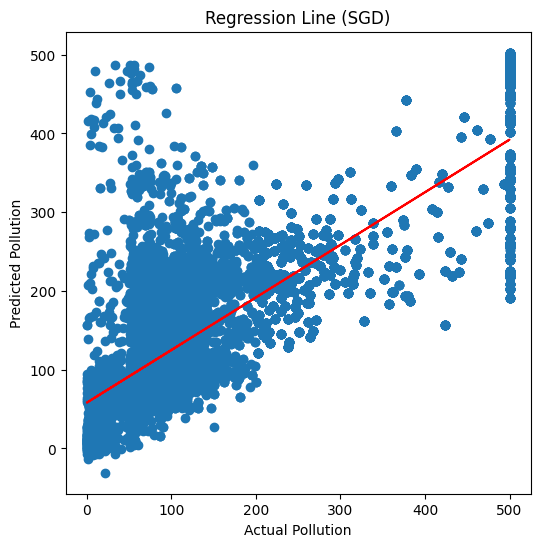

In [162]:
plt.figure(figsize=(6,6))
plt.scatter(y_under_test, y_pred_under_3)

# regression line (red color)
z = np.polyfit(y_under_test, y_pred_under_3, 1)
p = np.poly1d(z)
plt.plot(y_under_test, p(y_under_test), color='red')

plt.xlabel("Actual Pollution")
plt.ylabel("Predicted Pollution")
plt.title("Regression Line (SGD)")
plt.show()
